In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [3]:
import pandas as pd

path = "/kaggle/input/brazilian-ecommerce"

orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{path}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

print("✅ orders:", orders.shape)
print("✅ reviews:", reviews.shape)
print("✅ items:", items.shape)
print("✅ payments:", payments.shape)
print("✅ customers:", customers.shape)
print("✅ products:", products.shape)
print("✅ sellers:", sellers.shape)
print("✅ geolocation:", geolocation.shape)
print("✅ category_translation:", category_translation.shape)

✅ orders: (99441, 8)
✅ reviews: (99224, 7)
✅ items: (112650, 7)
✅ payments: (103886, 5)
✅ customers: (99441, 5)
✅ products: (32951, 9)
✅ sellers: (3095, 4)
✅ geolocation: (1000163, 5)
✅ category_translation: (71, 2)


In [4]:
# Exploración inicial de todas las tablas
tablas = {
    "orders": orders,
    "reviews": reviews,
    "items": items,
    "payments": payments,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for nombre, df in tablas.items():
    print(f"\n{'='*40}")
    print(f"📋 TABLA: {nombre.upper()}")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
    print(f"Columnas: {list(df.columns)}")
    print(f"Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


📋 TABLA: ORDERS
Filas: 99441 | Columnas: 8
Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Nulos:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

📋 TABLA: REVIEWS
Filas: 99224 | Columnas: 7
Columnas: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
Nulos:
review_comment_title      87656
review_comment_message    58247
dtype: int64

📋 TABLA: ITEMS
Filas: 112650 | Columnas: 7
Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Nulos:
Series([], dtype: int64)

📋 TABLA: PAYMENTS
Filas: 103886 | Columnas: 5
Columnas: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value'

In [5]:
for nombre, df in tablas.items():
    print(f"\n{'='*40}")
    print(f"📋 TABLA: {nombre.upper()}")
    print(f"\n🔍 Primeras 2 filas:")
    display(df.head(2))
    print(f"\n📊 Tipos de datos:")
    print(df.dtypes)
    print(f"\n❌ Nulos:")
    print(df.isnull().sum())


📋 TABLA: ORDERS

🔍 Primeras 2 filas:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00



📊 Tipos de datos:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

❌ Nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

📋 TABLA: REVIEWS

🔍 Primeras 2 filas:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13



📊 Tipos de datos:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

❌ Nulos:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

📋 TABLA: ITEMS

🔍 Primeras 2 filas:


...


📊 Tipos de datos:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object

❌ Nulos:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

📋 TABLA: GEOLOCATION

🔍 Primeras 2 filas:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP



📊 Tipos de datos:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

❌ Nulos:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

📋 TABLA: CATEGORY_TRANSLATION

🔍 Primeras 2 filas:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories



📊 Tipos de datos:
product_category_name            object
product_category_name_english    object
dtype: object

❌ Nulos:
product_category_name            0
product_category_name_english    0
dtype: int64


📊 Distribución del review_score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Promedio: 4.09
Mediana: 5.0


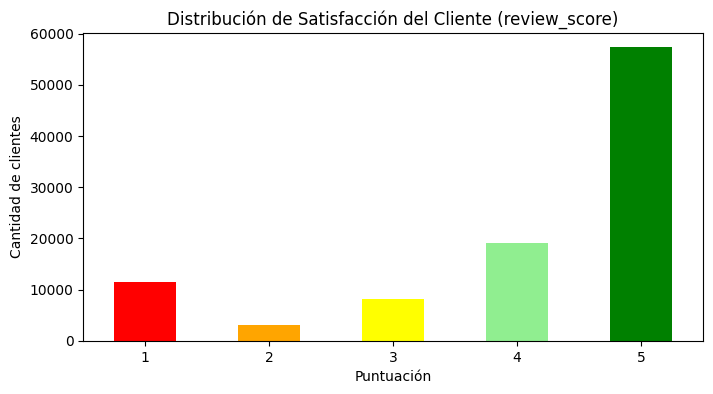

In [6]:
import matplotlib.pyplot as plt

# Distribución del review_score
print("📊 Distribución del review_score:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nPromedio: {reviews['review_score'].mean():.2f}")
print(f"Mediana: {reviews['review_score'].median()}")

# Gráfica
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar',
    color=['red','orange','yellow','lightgreen','green'],
    figsize=(8,4)
)
plt.title('Distribución de Satisfacción del Cliente (review_score)')
plt.xlabel('Puntuación')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.show()

In [7]:
# Clasificar satisfechos vs insatisfechos
reviews['satisfecho'] = reviews['review_score'].apply(
    lambda x: 'Satisfecho (4-5)' if x >= 4 else 'Insatisfecho (1-3)'
)

print(reviews['satisfecho'].value_counts())
print("\n%:")
print(reviews['satisfecho'].value_counts(normalize=True) * 100)

satisfecho
Satisfecho (4-5)      76470
Insatisfecho (1-3)    22754
Name: count, dtype: int64

%:
satisfecho
Satisfecho (4-5)      77.068048
Insatisfecho (1-3)    22.931952
Name: proportion, dtype: float64


In [8]:
# MASTER TABLE - Predicción Satisfacción del Cliente
master = orders.merge(
    reviews[['order_id','review_score','satisfecho']],
    on='order_id', how='left'
)
master = master.merge(
    customers,
    on='customer_id', how='left'
)
master = master.merge(
    payments.groupby('order_id').agg(
        payment_value=('payment_value','sum'),
        payment_installments=('payment_installments','max'),
        payment_type=('payment_type','first')
    ).reset_index(),
    on='order_id', how='left'
)
master = master.merge(
    items.groupby('order_id').agg(
        total_items=('order_item_id','count'),
        total_price=('price','sum'),
        total_freight=('freight_value','sum')
    ).reset_index(),
    on='order_id', how='left'
)

print("✅ Master Table creada!")
print(f"Filas: {master.shape[0]} | Columnas: {master.shape[1]}")
display(master.head(3))

✅ Master Table creada!
Filas: 99992 | Columnas: 20


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,satisfecho,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_type,total_items,total_price,total_freight
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,Satisfecho (4-5),7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,credit_card,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,Satisfecho (4-5),af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,Satisfecho (4-5),3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,1.0,159.90,19.22


In [9]:
# Verificar periodo y volumen de pedidos
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("📦 Total de pedidos:", orders.shape[0])
print("📅 Fecha más antigua:", orders['order_purchase_timestamp'].min())
print("📅 Fecha más reciente:", orders['order_purchase_timestamp'].max())
print("📆 Años cubiertos:", orders['order_purchase_timestamp'].dt.year.unique())

📦 Total de pedidos: 99441
📅 Fecha más antigua: 2016-09-04 21:15:19
📅 Fecha más reciente: 2018-10-17 17:30:18
📆 Años cubiertos: [2017 2018 2016]


In [10]:
# EDA - Análisis de valores nulos y tipos de datos
print("📊 INFORMACIÓN GENERAL DE LA MASTER TABLE")
print(f"Filas: {master.shape[0]} | Columnas: {master.shape[1]}")
print("\n❌ Valores nulos por columna:")
nulos = master.isnull().sum()
print(nulos[nulos > 0])

📊 INFORMACIÓN GENERAL DE LA MASTER TABLE
Filas: 99992 | Columnas: 20

❌ Valores nulos por columna:
order_approved_at                 161
order_delivered_carrier_date     1793
order_delivered_customer_date    2987
review_score                      768
satisfecho                        768
payment_value                       1
payment_installments                1
payment_type                        1
total_items                       778
total_price                       778
total_freight                     778
dtype: int64


In [11]:
print("📊 Estadísticas descriptivas:")
display(master[['review_score', 'payment_value',
                'total_items', 'total_price',
                'total_freight', 'payment_installments']].describe())

📊 Estadísticas descriptivas:


,review_score,payment_value,total_items,total_price,total_freight,payment_installments
count,99224.000000,99991.000000,99214.000000,99214.000000,99214.000000,99991.000000
mean,4.086421,160.828682,1.142117,137.600777,22.818845,2.934044
std,1.347579,221.580101,0.539605,210.284622,21.624222,2.718827
min,1.000000,0.000000,1.000000,0.850000,0.000000,0.000000
25%,4.000000,61.990000,1.000000,45.900000,13.850000,1.000000
50%,5.000000,105.280000,1.000000,86.800000,17.170000,2.000000
75%,5.000000,176.830000,1.000000,149.900000,24.050000,4.000000
max,5.000000,13664.080000,21.000000,13440.000000,1794.960000,24.000000


review_score promedio: 4.09 → clientes generalmente satisfechos
payment_value máximo: $13,664 → hay outliers de pagos muy altos ⚠️
total_price máximo: $13,440 → outliers en precios ⚠️
total_freight máximo: $1,794 → flete muy alto en algunos casos ⚠️
payment_installments máximo: 24 → algunos pagan en 24 cuotas

In [12]:
# Convertir fechas
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])
master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'])

# Calcular variables clave
master['dias_entrega'] = (master['order_delivered_customer_date'] -
                          master['order_purchase_timestamp']).dt.days

master['dias_retraso'] = (master['order_delivered_customer_date'] -
                          master['order_estimated_delivery_date']).dt.days

master['es_tarde'] = (master['dias_retraso'] > 0).astype(int)

print("✅ Variables de tiempo creadas!")
print(master[['dias_entrega','dias_retraso','es_tarde']].describe())

✅ Variables de tiempo creadas!
       dias_entrega  dias_retraso      es_tarde
count  97005.000000  97005.000000  99992.000000
mean      12.100015    -11.880790      0.065635
std        9.547959     10.183992      0.247645
min        0.000000   -147.000000      0.000000
25%        6.000000    -17.000000      0.000000
50%       10.000000    -12.000000      0.000000
75%       15.000000     -7.000000      0.000000
max      209.000000    188.000000      1.000000


Días entrega promedio: 12 días → casi 2 semanas
días_retraso promedio: -11 días → en general llegan ANTES de lo estimado ✅
es_tarde: 6.5% → solo el 6.5% llega tarde ⚠️
Max días entrega: 209 días → outlier extremo ⚠️
Max retraso: 188 días → outlier extremo ⚠️

📊 Satisfacción promedio:
es_tarde
0    4.211789
1    2.271139
Name: review_score, dtype: float64


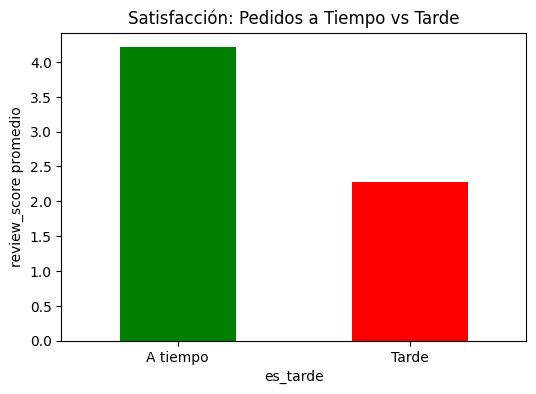

In [16]:
import matplotlib.pyplot as plt

# Satisfacción promedio: tarde vs a tiempo
retraso_score = master.groupby('es_tarde')['review_score'].mean()
print("📊 Satisfacción promedio:")
print(retraso_score)

retraso_score.plot(kind='bar',
                   color=['green','red'],
                   figsize=(6,4))
plt.title('Satisfacción: Pedidos a Tiempo vs Tarde')
plt.xticks([0,1], ['A tiempo','Tarde'], rotation=0)
plt.ylabel('review_score promedio')
plt.show()

A tiempo: 4.21 ⭐ vs Tarde: 2.27 ⭐
¡Casi el doble de satisfacción cuando llega a tiempo!
Esto confirma H1 al 100% ✅

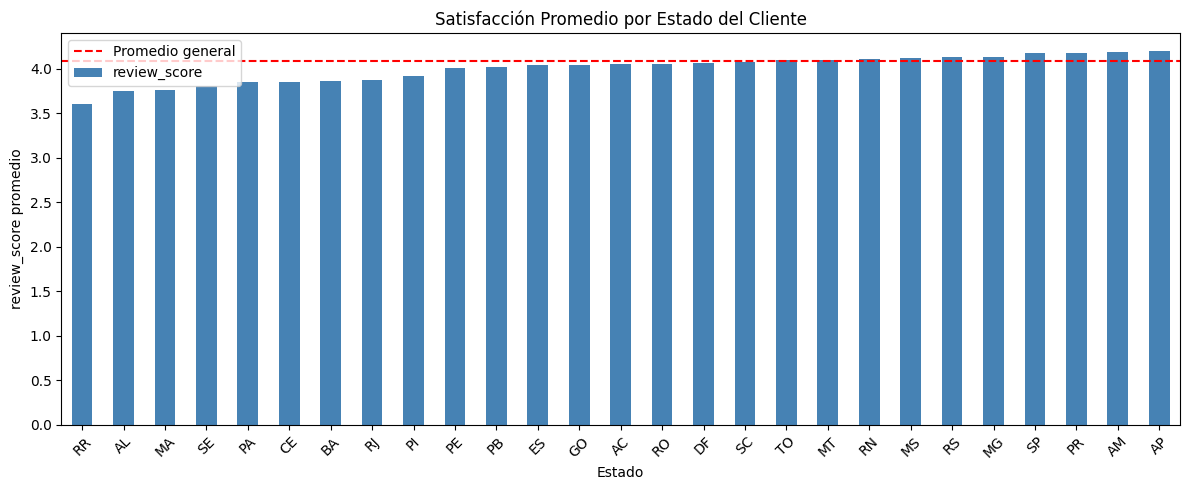

In [15]:
# Satisfacción promedio por estado
score_estado = master.groupby('customer_state')['review_score'].mean().sort_values()

plt.figure(figsize=(12,5))
score_estado.plot(kind='bar', color='steelblue')
plt.title('Satisfacción Promedio por Estado del Cliente')
plt.xlabel('Estado')
plt.ylabel('review_score promedio')
plt.xticks(rotation=45)
plt.axhline(y=master['review_score'].mean(),
            color='red', linestyle='--', label='Promedio general')
plt.legend()
plt.tight_layout()
plt.show()

RR, AL, MA → estados con menor satisfacción (debajo del promedio)
AP, AM, PR → estados con mayor satisfacción
Estados del norte de Brasil tienen menor satisfacción → más lejos de los centros de distribución

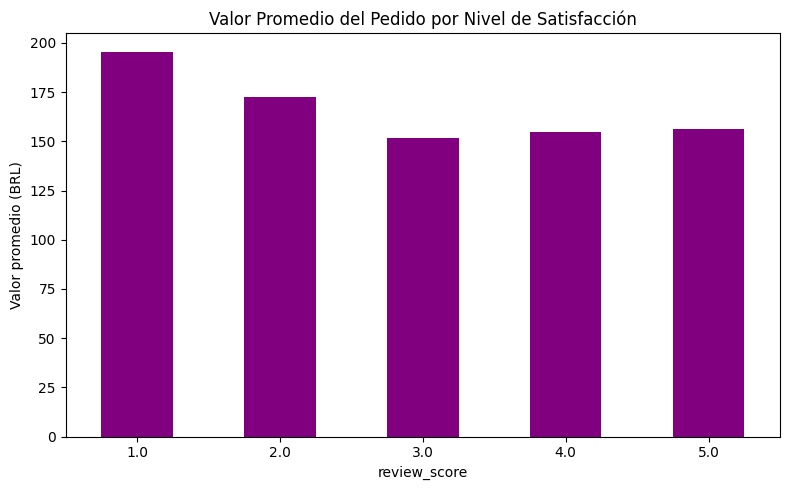

In [17]:
# Satisfacción vs valor del pedido
plt.figure(figsize=(8,5))
master.groupby('review_score')['payment_value'].mean().plot(
    kind='bar', color='purple')
plt.title('Valor Promedio del Pedido por Nivel de Satisfacción')
plt.xlabel('review_score')
plt.ylabel('Valor promedio (BRL)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Hallazgo interesante! ¡Rechaza H2!

Score 1 → $195 BRL → los más insatisfechos gastaron MÁS
Score 5 → $156 BRL → los más satisfechos gastaron menos
✅ Esto rechaza H2 — mayor valor NO significa mayor satisfacción
🎯 Muy bueno para defender — muestra pensamiento crítico!

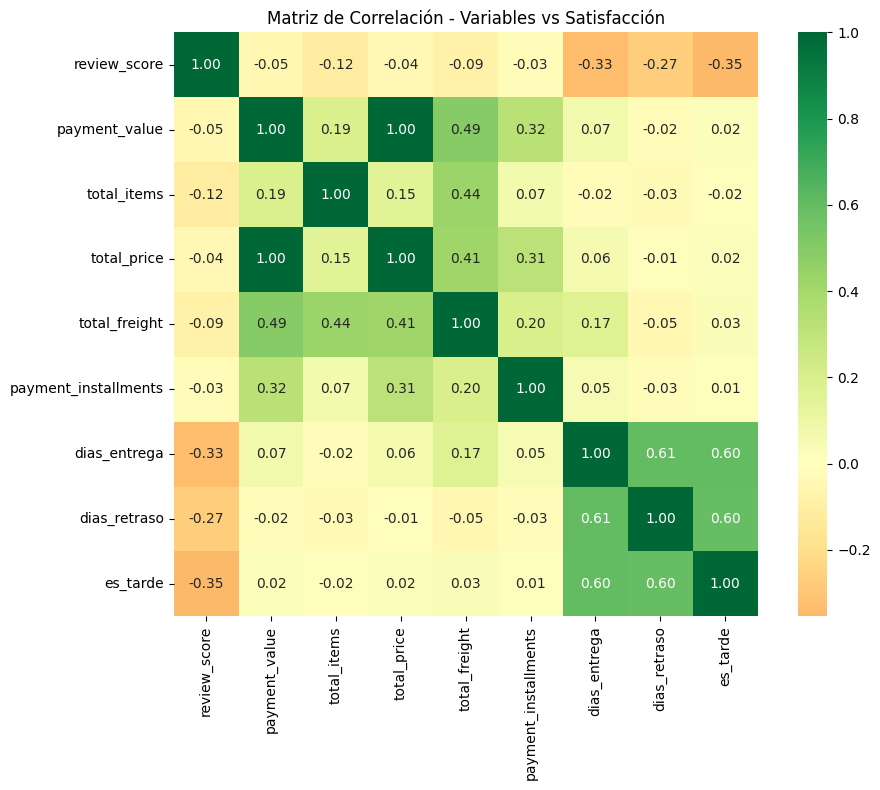

In [18]:
import seaborn as sns

# Matriz de correlación
variables = ['review_score', 'payment_value', 'total_items',
             'total_price', 'total_freight',
             'payment_installments', 'dias_entrega', 'dias_retraso', 'es_tarde']

corr = master[variables].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True)
plt.title('Matriz de Correlación - Variables vs Satisfacción')
plt.tight_layout()
plt.show()

es_tarde: -0.35 → ¡La más importante! ⭐
dias_entrega: -0.33 → Segunda más importante
dias_retraso: -0.27 → Tercera
total_items: -0.12 → Algo de relación

In [19]:
# ============================================
# KPIs - Predicción Satisfacción del Cliente
# ============================================

# KPI 1 - Customer Satisfaction Rate
csat = (master[master['review_score'] >= 4].shape[0] /
        master['review_score'].dropna().shape[0]) * 100

# KPI 2 - Unsatisfied Customer Rate
unsat = (master[master['review_score'] <= 3].shape[0] /
         master['review_score'].dropna().shape[0]) * 100

# KPI 3 - Average Review Score
avg_score = master['review_score'].mean()

# KPI 4 - Late Delivery Rate
late_rate = (master['es_tarde'].sum() /
             master['es_tarde'].dropna().shape[0]) * 100

# KPI 5 - Average Delivery Delay
avg_delay = master['dias_retraso'].mean()

# KPI 6 - Revenue at Risk
revenue_risk = master[master['review_score'] <= 3]['payment_value'].sum()

# KPI 7 - Average Order Value
aov = master['payment_value'].mean()

# KPI 8 - Satisfaction by State
sat_state = master.groupby('customer_state')['review_score'].mean()

# KPI 9 - Satisfaction by Payment Type
sat_payment = master.groupby('payment_type')['review_score'].mean()

# KPI 10 - Satisfaction by Product Quantity
sat_quantity = master.groupby('total_items')['review_score'].mean()

# ============================================
print("📊 RESUMEN DE KPIs")
print(f"1. Customer Satisfaction Rate:    {csat:.2f}%")
print(f"2. Unsatisfied Customer Rate:     {unsat:.2f}%")
print(f"3. Average Review Score:          {avg_score:.2f}")
print(f"4. Late Delivery Rate:            {late_rate:.2f}%")
print(f"5. Average Delivery Delay:        {avg_delay:.2f} días")
print(f"6. Revenue at Risk:               ${revenue_risk:,.2f} BRL")
print(f"7. Average Order Value (AOV):     ${aov:.2f} BRL")
print(f"\n8. Satisfaction by State:\n{sat_state.sort_values()}")
print(f"\n9. Satisfaction by Payment Type:\n{sat_payment}")
print(f"\n10. Satisfaction by Quantity:\n{sat_quantity}")

📊 RESUMEN DE KPIs
1. Customer Satisfaction Rate:    77.07%
2. Unsatisfied Customer Rate:     22.93%
3. Average Review Score:          4.09
4. Late Delivery Rate:            6.56%
5. Average Delivery Delay:        -11.88 días
6. Revenue at Risk:               $4,015,732.14 BRL
7. Average Order Value (AOV):     $160.83 BRL

8. Satisfaction by State:
customer_state
RR    3.608696
AL    3.751208
MA    3.764075
SE    3.808023
PA    3.849174
CE    3.851016
BA    3.860888
RJ    3.874971
PI    3.920570
PE    4.011543
PB    4.018832
ES    4.041667
GO    4.042490
AC    4.049383
RO    4.051587
DF    4.064711
SC    4.071764
TO    4.096774
MT    4.102990
RN    4.105809
MS    4.118785
RS    4.133321
MG    4.136172
SP    4.173951
PR    4.180032
AM    4.183673
AP    4.194030
Name: review_score, dtype: float64

9. Satisfaction by Payment Type:
payment_type
boleto         4.086631
credit_card    4.087886
debit_card     4.168194
not_defined    1.666667
voucher        4.002564
Name: review_score, dtype: f

KPI 1 y 2: 77% satisfechos vs 23% insatisfechos → desbalance de clases confirmado
KPI 4: Solo 6.56% llega tarde → pero su impacto es ENORME (score 2.27 vs 4.21)
KPI 5: -11.88 días → en promedio llegan 12 días ANTES de lo estimado ✅
KPI 6: ⚠️ $4 millones BRL en riesgo → clientes insatisfechos que podrían no volver
KPI 9: not_defined tiene score 1.67 → pagos sin definir son problemáticos
KPI 10: Con 1 item → 4.16 pero con 7 items → 2.9 → confirma H4 ✅

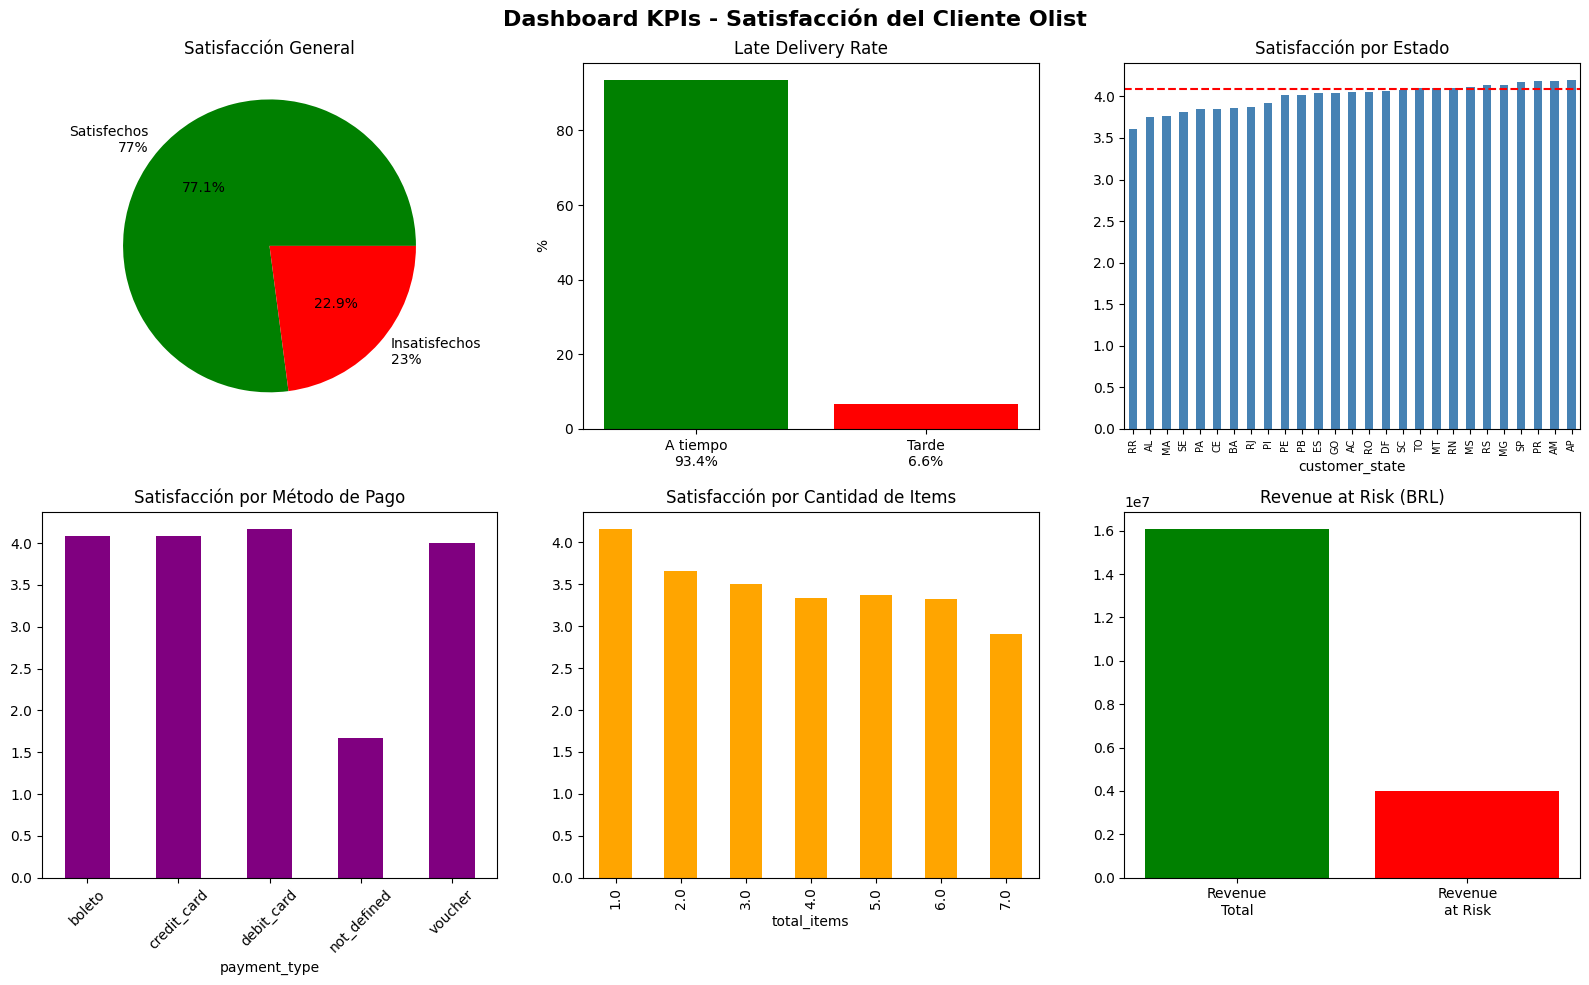

In [22]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Dashboard KPIs - Satisfacción del Cliente Olist',
             fontsize=16, fontweight='bold')

# KPI 1 y 2 - Satisfechos vs Insatisfechos
axes[0,0].pie([77.07, 22.93],
              labels=['Satisfechos\n77%', 'Insatisfechos\n23%'],
              colors=['green','red'], autopct='%1.1f%%')
axes[0,0].set_title('Satisfacción General')

# KPI 4 - Late Delivery Rate
axes[0,1].bar(['A tiempo\n93.4%', 'Tarde\n6.6%'],
              [93.44, 6.56], color=['green','red'])
axes[0,1].set_title('Late Delivery Rate')
axes[0,1].set_ylabel('%')

# KPI 8 - Por Estado
sat_state.sort_values().plot(kind='bar', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Satisfacción por Estado')
axes[0,2].tick_params(axis='x', labelsize=7)
axes[0,2].axhline(y=4.09, color='red', linestyle='--')

# KPI 9 - Por método de pago
sat_payment.plot(kind='bar', ax=axes[1,0], color='purple')
axes[1,0].set_title('Satisfacción por Método de Pago')
axes[1,0].tick_params(axis='x', rotation=45)

# KPI 10 - Por cantidad de productos
sat_quantity.head(7).plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Satisfacción por Cantidad de Items')

# KPI 6 - Revenue at Risk
axes[1,2].bar(['Revenue\nTotal', 'Revenue\nat Risk'],
              [master['payment_value'].sum(), 4015732.14],
              color=['green','red'])
axes[1,2].set_title('Revenue at Risk (BRL)')

plt.tight_layout()
plt.show()
